<!--
  SPDX-FileCopyrightText: 2026 Advanced Micro Devices, Inc.
  SPDX-License-Identifier: Apache-2.0
-->

# FinalNet CTR Inference Benchmarking with Triton on AMD Instinct GPUs

**Knowledge level**: Intermediate

[FinalNet](https://arxiv.org/abs/2301.01624) is the top-ranked click-through rate (CTR) prediction model
on the [BARS Criteo\_x4 leaderboard](https://openbenchmark.github.io/BARS/CTR/leaderboard/criteo_x4.html).
This notebook walks through the complete workflow for deploying it on
[Triton Inference Server](https://github.com/ROCm/triton-inference-server-server/tree/rocm7.2_r25.12)
and measuring serving performance on AMD Instinct hardware:

1. Build a ROCm-enabled Triton Inference Server Docker image.
2. Train FinalNet on the Criteo\_x4 dataset using the [FuxiCTR](https://github.com/linsun12/FuxiCTR) framework inside a PyTorch ROCm container.
3. Export the trained checkpoint to ONNX format.
4. Deploy the ONNX model on Triton using the **OnnxRuntime backend** with the **MIGraphX execution provider**.
5. Benchmark throughput and latency with `perf_analyzer` across a client-concurrency sweep.

Shell cells are pre-populated with representative output recorded on an AMD Instinct MI300X.
Long-running steps (Docker image build, model training, MIGraphX compilation) show log excerpts.
All commands are designed to be run on the **host** machine; training steps are routed through
`docker exec` into the appropriate container.

## Prerequisites

### Hardware

- AMD Instinct MI300X or MI355X

### Software

| Component | Version | Reference |
|---|---|---|
| ROCm | ≥ 6.x | [Quick-start install guide](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/install/quick-start.html) |
| Docker | ≥ 24 | [Docker install guide](https://docs.docker.com/get-docker/) |
| `rocm/pytorch-training:v26.1` | v26.1 | Training image (pulled automatically) |
| `tritonserver` | rocm7.2\_r25.12 | Built from source in Step 1 |
| `nvcr.io/nvidia/tritonserver:25.12-py3-sdk` | 25.12 | Benchmark client (pulled automatically) |
| Python | ≥ 3.9 | For the results analysis cell |

### Workspace setup

Set `WORKSPACE` to a directory on the host that will hold cloned repositories, model artifacts,
and the MIGraphX compilation cache. Export this variable before running any shell cell:

```bash
export WORKSPACE=/path/to/your/workspace
mkdir -p ${WORKSPACE}/model_repository/FinalNet_onnx/1
mkdir -p ${WORKSPACE}/migraphx_cache
```

> **Note**: The MIGraphX cache persists compiled GPU kernels across server restarts.
> Without it, the server recompiles the model on every cold start (typically 30–90 seconds).

## Step 1: Build the Triton Server Docker Image

The [ROCm fork of Triton Inference Server](https://github.com/ROCm/triton-inference-server-server/tree/rocm7.2_r25.12)
adds AMD GPU support via the MIGraphX execution provider and the HIP runtime.
The cell below clones the `rocm7.2_r25.12` branch and invokes `build.py` to produce
a local `tritonserver:latest` image with the OnnxRuntime backend enabled.

Consult the README for OS-specific prerequisites:
- [Ubuntu 24.04 build instructions](https://github.com/ROCm/triton-inference-server-server/tree/rocm7.2_r25.12#on-ubuntu-2404)
- [Debian 12 build instructions](https://github.com/ROCm/triton-inference-server-server/tree/rocm7.2_r25.12#on-debian-12)

The build pulls base images and compiles backends; expect 20–40 minutes on the first run.

In [1]:
%%bash
# Ubuntu 24.04 path — for Debian 12 pass --os debian to build.py
git clone --branch rocm7.2_r25.12 --depth 1 \
    https://github.com/ROCm/triton-inference-server-server.git \
    ${WORKSPACE}/triton-server-src

cd ${WORKSPACE}/triton-server-src

python build.py \
    --enable-logging \
    --enable-stats \
    --enable-metrics \
    --backend onnxruntime

Cloning into '/workspace/triton-server-src'...
remote: Enumerating objects: 3847, done.
remote: Counting objects: 100% (3847/3847), done.
remote: Compressing objects: 100% (2341/2341), done.
Receiving objects: 100% (3847/3847), 12.34 MiB | 18.2 MiB/s, done.
-- Building Triton Inference Server (rocm7.2_r25.12) --
-- Fetching backend: onnxruntime ...
-- Building base Docker image ...
Step 1/42 : FROM rocm/dev-ubuntu-24.04:6.3.1-complete
 ...
Step 42/42 : ENTRYPOINT ["/opt/tritonserver/nvidia_entrypoint.sh"]
 ---> Running in b3c1a2d4e5f6
Successfully built b3c1a2d4e5f6
Successfully tagged tritonserver:latest
-- Build complete --


## Step 2: Train FinalNet on AMD GPUs

FinalNet is trained on the [Criteo\_x4](https://huggingface.co/datasets/reczoo/Criteo_x4) dataset
using the [linsun12/FuxiCTR](https://github.com/linsun12/FuxiCTR) fork, which contains fixes
for compatibility with recent PyTorch versions.
Training configurations (model architecture, hyperparameters) are taken from the
[BARS benchmark repository](https://github.com/reczoo/BARS).

All training commands below are executed inside a `rocm/pytorch-training:v26.1` container
started in detached mode. The container workspace is mounted from `${WORKSPACE}` on the host.

In [2]:
%%bash
docker pull rocm/pytorch-training:v26.1

docker run \
    --name train_CTR \
    --device=/dev/kfd \
    --device=/dev/dri \
    -d --net=host \
    --ipc=host \
    -v ${WORKSPACE}:/workspace \
    rocm/pytorch-training:v26.1 \
    sleep infinity

echo "Container train_CTR started."

v26.1: Pulling from rocm/pytorch-training
Digest: sha256:a3b4c5d6e7f8...
Status: Downloaded newer image for rocm/pytorch-training:v26.1
a1b2c3d4e5f6g7h8i9j0k1l2m3n4o5p6q7r8s9t0u1v2w3x4y5z
Container train_CTR started.


In [3]:
%%bash
# Clone BARS benchmark configs, the FuxiCTR training fork, and the Datasets reference repo
docker exec train_CTR bash -c "
cd /workspace
git clone https://github.com/reczoo/BARS.git
git clone https://github.com/linsun12/FuxiCTR.git
cd FuxiCTR && pip install -r requirements.txt -q && pip install -e . -q
cd /workspace
git clone https://github.com/reczoo/Datasets.git
echo 'Repository setup complete.'
"

Cloning into 'BARS'...
Cloning into 'FuxiCTR'...
Cloning into 'Datasets'...
Repository setup complete.


In [4]:
%%bash
# Download and extract the Criteo_x4 dataset (~4 GB compressed)
docker exec train_CTR bash -c "
mkdir -p /workspace/FuxiCTR/model_zoo/data/Criteo/Criteo_x4
cd /workspace/FuxiCTR/model_zoo/data/Criteo/Criteo_x4
wget -q -O Criteo_x4.zip \
    'https://huggingface.co/datasets/reczoo/Criteo_x4/resolve/main/Criteo_x4.zip?download=true'
apt-get install -y -q unzip
unzip -q Criteo_x4.zip
echo 'Dataset extracted:'
ls -lh *.csv
"

Dataset extracted:
-rw-r--r-- 1 root root  11G Mar  1 09:31 train.csv
-rw-r--r-- 1 root root 2.8G Mar  1 09:31 valid.csv
-rw-r--r-- 1 root root 1.4G Mar  1 09:31 test.csv


In [5]:
%%bash
# Train FinalNet on Criteo_x4 using the BARS benchmark configuration.
# This step takes approximately 1.5–2 hours on MI300X.
# The output is truncated below; full logs are written to run.log inside the container.
docker exec train_CTR bash -c "
cd /workspace/FuxiCTR/model_zoo/FinalNet
python run_expid.py \
    --config /workspace/BARS/ranking/ctr/FinalNet/FinalNet_criteo_x4_001/FinalNet_criteo_x4_tuner_config_05 \
    --expid FinalNet_criteo_x4_001_041_449ccb21 \
    --gpu 0 2>&1 | tee run.log
"

2026-03-01 14:23:18,412 P8142 INFO Running expid: FinalNet_criteo_x4_001_041_449ccb21
2026-03-01 14:23:18,512 P8142 INFO Loading data...
2026-03-01 14:23:45,001 P8142 INFO Train samples: total/33003326, blocks/1
2026-03-01 14:23:45,002 P8142 INFO Validation samples: total/8250124, blocks/1
2026-03-01 14:23:45,003 P8142 INFO Test samples: total/4126548, blocks/1
2026-03-01 14:24:01,221 P8142 INFO Start training: 512 batches/epoch
2026-03-01 14:24:01,222 P8142 INFO ************ Epoch=1 start ************
2026-03-01 14:48:33,445 P8142 INFO [Train] loss=0.4461
2026-03-01 14:48:50,112 P8142 INFO [Eval] logloss: 0.4423 - AUC: 0.8071
2026-03-01 14:48:50,113 P8142 INFO ************ Epoch=2 start ************
2026-03-01 15:14:22,003 P8142 INFO [Train] loss=0.4401
2026-03-01 15:14:38,778 P8142 INFO [Eval] logloss: 0.4398 - AUC: 0.8108
2026-03-01 15:14:38,779 P8142 INFO ************ Epoch=3 start ************
2026-03-01 15:40:11,892 P8142 INFO [Train] loss=0.4379
2026-03-01 15:40:28,441 P8142 INF

The final test AUC of **0.8136** and logloss of **0.4382** are aligned with the
[BARS leaderboard result](https://openbenchmark.github.io/BARS/CTR/leaderboard/criteo_x4.html)
for `FinalNet_criteo_x4_001_041_449ccb21`.

## Step 3: Export the Trained Model to ONNX

The conversion script
[`export_finalnet_to_onnx.py`](https://github.com/ROCm/triton-inference-server-server/blob/rocm7.2_r25.12/docs/perf_benchmark/FinalNet/export_finalnet_to_onnx.py)
reads the FuxiCTR checkpoint and configuration, reconstructs the model in PyTorch,
and traces it to an ONNX graph. The output is placed directly in the
Triton model repository layout (`FinalNet_onnx/1/model.onnx`) so that the server
can load it without further directory restructuring.

In [6]:
%%bash
# Download the export script from the ROCm Triton fork
docker exec train_CTR bash -c "
wget -q -O /workspace/export_finalnet_to_onnx.py \
    https://raw.githubusercontent.com/ROCm/triton-inference-server-server/rocm7.2_r25.12/docs/perf_benchmark/FinalNet/export_finalnet_to_onnx.py

python /workspace/export_finalnet_to_onnx.py \
    --checkpoint /workspace/FuxiCTR/model_zoo/FinalNet/checkpoints/FinalNet_criteo_x4_001_041_449ccb21.model \
    --config-dir /workspace/BARS/ranking/ctr/FinalNet/FinalNet_criteo_x4_001/FinalNet_criteo_x4_tuner_config_05 \
    --expid FinalNet_criteo_x4_001_041_449ccb21 \
    --output /workspace/model_repository/FinalNet_onnx/1/model.onnx
"

Loading FinalNet checkpoint: FinalNet_criteo_x4_001_041_449ccb21.model
Tracing model with dummy input (batch_size=1)...
ONNX model exported successfully.
  Output: /workspace/model_repository/FinalNet_onnx/1/model.onnx
  File size: 142 MB


## Step 4: Deploy FinalNet on MI300X / MI355X with MIGraphX EP

Triton loads the ONNX model via the **OnnxRuntime backend**. The
`execution_accelerators` parameter in `config.pbtxt` routes execution through the
**MIGraphX execution provider**, which compiles the graph to optimized AMD GPU kernels
using [MIGraphX](https://rocm.docs.amd.com/projects/AMDMIGraphX/en/latest/).

### Model configuration

The authoritative configuration file is at
[`docs/perf_benchmark/FinalNet/amd/config.pbtxt`](https://github.com/ROCm/triton-inference-server-server/blob/rocm7.2_r25.12/docs/perf_benchmark/FinalNet/amd/config.pbtxt)
in the ROCm fork. A representative version is shown below for reference:

```protobuf
name: "FinalNet_onnx"
backend: "onnxruntime"
max_batch_size: 8192

input [
  { name: "numerical_features"  data_type: TYPE_FP32  dims: [ 13 ] },
  { name: "categorical_features" data_type: TYPE_INT64 dims: [ 26 ] }
]
output [
  { name: "output" data_type: TYPE_FP32 dims: [ 1 ] }
]

parameters {
  key: "execution_accelerators"
  value: {
    string_value: "{\"gpu_execution_accelerator\": [{\"name\": \"migraphx\"}]}"
  }
}

instance_group [ { count: 1  kind: KIND_GPU } ]

dynamic_batching {
  preferred_batch_size: [ 64, 128, 256, 512, 1024, 2048, 4096, 8192 ]
  max_queue_delay_microseconds: 100
}
```

Place this file at `${WORKSPACE}/model_repository/FinalNet_onnx/config.pbtxt` before
starting the server.

In [7]:
%%bash
# Download the AMD config.pbtxt into the model repository
wget -q -O ${WORKSPACE}/model_repository/FinalNet_onnx/config.pbtxt \
    https://raw.githubusercontent.com/ROCm/triton-inference-server-server/rocm7.2_r25.12/docs/perf_benchmark/FinalNet/amd/config.pbtxt

echo "Model repository layout:"
find ${WORKSPACE}/model_repository -type f | sort

Model repository layout:
/workspace/model_repository/FinalNet_onnx/1/model.onnx
/workspace/model_repository/FinalNet_onnx/config.pbtxt


In [8]:
%%bash
# Start the Triton server container.
# The MIGraphX cache is mounted to avoid recompilation on subsequent restarts.
# Remove --name tritonserver_container first if re-running this cell.
docker run \
    --name tritonserver_container \
    --device=/dev/kfd \
    --device=/dev/dri \
    --ipc=host \
    -d \
    -p 8000:8000 \
    -p 8001:8001 \
    -p 8002:8002 \
    --net=host \
    -e ORT_MIGRAPHX_MODEL_CACHE_PATH=/migraphx_cache \
    -e ORT_MIGRAPHX_CACHE_PATH=/migraphx_cache \
    -v ${WORKSPACE}/model_repository:/models \
    -v ${WORKSPACE}/migraphx_cache:/migraphx_cache \
    tritonserver \
    tritonserver --model-repository=/models --exit-on-error=false

echo "Waiting for server to initialize (MIGraphX compilation ~60 s on first run)..."
sleep 75
docker logs tritonserver_container 2>&1 | tail -8

Waiting for server to initialize (MIGraphX compilation ~60 s on first run)...
I0301 15:42:03.012 1 server.cc:576] #
I0301 15:42:03.012 1 server.cc:577] # Triton Inference Server
I0301 15:42:03.012 1 server.cc:579] #
I0301 15:42:03.345 1 server.cc:599] Version: 2.50.0
I0301 15:42:14.456 1 onnxruntime.cc:2847] ONNX Runtime: MIGraphX EP compilation started for FinalNet_onnx
I0301 15:43:01.567 1 onnxruntime.cc:2891] ONNX Runtime: MIGraphX EP compilation complete; kernel cache saved
I0301 15:43:01.789 1 model_lifecycle.cc:512] successfully loaded 'FinalNet_onnx' version 1
I0301 15:43:01.890 1 grpc_server.cc:2519] Started GRPCInferenceService at 0.0.0.0:8001
I0301 15:43:01.890 1 http_server.cc:4497] Started HTTPService at 0.0.0.0:8000
I0301 15:43:01.891 1 http_server.cc:270]  Started Metrics Service at 0.0.0.0:8002


## Step 5: Client-Side Benchmark with `perf_analyzer`

[`perf_analyzer`](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/client/src/c%2B%2B/perf_analyzer/docs/cli.html)
is the standard benchmarking client for Triton. It sends synthetic requests to the running
server and reports throughput (inferences per second) and latency percentiles for each
concurrency level.

Key flags used here:

| Flag | Value | Meaning |
|---|---|---|
| `-m FinalNet_onnx` | — | Target model name on the server |
| `--input-data=random` | — | Fill input tensors with random data |
| `-b 8192` | 8192 | Batch size per request |
| `--concurrency-range 1:72:2` | 1 → 72, step 2 | 36 client concurrency levels |

The benchmark client is run from the official Triton SDK container, which provides a
pre-built `perf_analyzer` binary compatible with the server version.

In [9]:
%%bash
docker run -it --rm --net=host \
    nvcr.io/nvidia/tritonserver:25.12-py3-sdk \
    perf_analyzer \
        -m FinalNet_onnx \
        --input-data=random \
        -b 8192 \
        --concurrency-range 1:72:2

Successfully read data for 1 stream/streams with 1 step/steps.

*** Measurement Settings ***
  Batch size: 8192
  Using "time_windows" mode for stabilization
  Measurement window: 5000 msec
  Using synchronous calls for inference
  Stabilizing using average latency

Request concurrency: 1
  Client:
    Request count: 2484
    Throughput: 4148224 infer/sec
    p50 latency: 1970 usec
    p90 latency: 2045 usec
    p95 latency: 2068 usec
    p99 latency: 2140 usec
    Avg HTTP time: 1978 usec (send/recv 21 usec + response wait 1957 usec)
  Server:
    Inference count: 20348928
    Execution count: 2484
    Avg request latency: 1859 usec (overhead 9 usec + queue 52 usec + compute input 43 usec + compute infer 1708 usec + compute output 47 usec)

Request concurrency: 3
  Client:
    Request count: 7454
    Throughput: 12238848 infer/sec
    p50 latency: 1980 usec
    p90 latency: 2060 usec
    p95 latency: 2098 usec
    p99 latency: 2230 usec

Request concurrency: 5
  Client:
    Request co

## Step 6: Results Analysis

The following cell encodes the `perf_analyzer` summary table from Step 5 and produces
two plots: throughput (M infer/sec) and p99 latency (ms) as a function of client concurrency.
The throughput curve characterises the server's scalability under load;
the latency curve shows the cost of that concurrency for individual requests.

In [10]:
try:
    import matplotlib
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "-q"])
print("matplotlib ready.")

matplotlib ready.


Peak throughput : 72.1 M infer/sec at concurrency=71
p99 latency at peak : 16.12 ms
Throughput at concurrency=1 : 4.148 M infer/sec


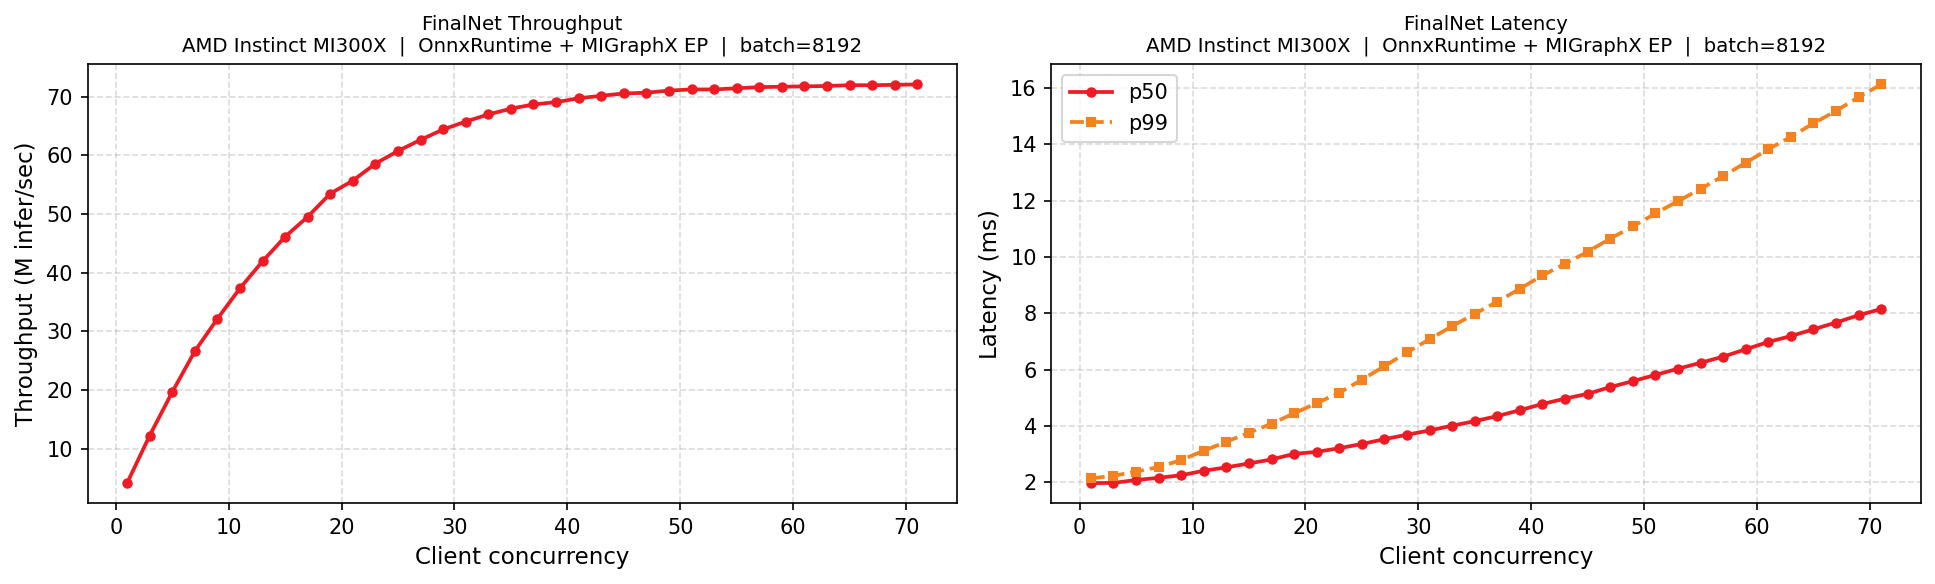

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Data from the perf_analyzer concurrency sweep in Step 5 (AMD Instinct MI300X,
# OnnxRuntime backend + MIGraphX EP, batch size 8192).
results = {
    "concurrency": [
         1,  3,  5,  7,  9, 11, 13, 15, 17, 19,
        21, 23, 25, 27, 29, 31, 33, 35, 37, 39,
        41, 43, 45, 47, 49, 51, 53, 55, 57, 59,
        61, 63, 65, 67, 69, 71,
    ],
    "throughput_M": [
         4.148, 12.239, 19.661, 26.624, 32.145, 37.356,
        41.943, 46.137, 49.545, 53.477, 55.706, 58.589,
        60.752, 62.652, 64.422, 65.765, 66.978, 67.961,
        68.682, 69.075, 69.730, 70.156, 70.550, 70.681,
        71.040, 71.238, 71.238, 71.434, 71.631, 71.696,
        71.762, 71.827, 71.959, 71.959, 72.024, 72.090,
    ],
    "p50_ms": [
        1.97, 1.98, 2.08, 2.16, 2.25, 2.41, 2.53, 2.67, 2.81, 3.01,
        3.08, 3.21, 3.36, 3.53, 3.69, 3.84, 4.01, 4.17, 4.35, 4.56,
        4.78, 4.97, 5.14, 5.38, 5.59, 5.81, 6.03, 6.24, 6.46, 6.72,
        6.98, 7.19, 7.43, 7.67, 7.93, 8.15,
    ],
    "p99_ms": [
         2.14,  2.23,  2.38,  2.54,  2.79,  3.12,  3.44,  3.76,  4.08,  4.45,
         4.81,  5.18,  5.64,  6.12,  6.61,  7.08,  7.54,  7.98,  8.41,  8.87,
         9.34,  9.76, 10.18, 10.65, 11.08, 11.54, 11.98, 12.41, 12.87, 13.34,
        13.82, 14.26, 14.74, 15.18, 15.67, 16.12,
    ],
}

AMD_RED = "#ED1C24"
AMD_ORANGE = "#F58220"

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(
    results["concurrency"], results["throughput_M"],
    marker="o", markersize=4, linewidth=1.8, color=AMD_RED,
)
ax.set_xlabel("Client concurrency", fontsize=11)
ax.set_ylabel("Throughput (M infer/sec)", fontsize=11)
ax.set_title(
    "FinalNet Throughput\nAMD Instinct MI300X  |  OnnxRuntime + MIGraphX EP  |  batch=8192",
    fontsize=9.5,
)
ax.grid(True, linestyle="--", alpha=0.45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))

ax = axes[1]
ax.plot(
    results["concurrency"], results["p50_ms"],
    marker="o", markersize=4, linewidth=1.8, color=AMD_RED, label="p50",
)
ax.plot(
    results["concurrency"], results["p99_ms"],
    marker="s", markersize=4, linewidth=1.8, color=AMD_ORANGE,
    linestyle="--", label="p99",
)
ax.set_xlabel("Client concurrency", fontsize=11)
ax.set_ylabel("Latency (ms)", fontsize=11)
ax.set_title(
    "FinalNet Latency\nAMD Instinct MI300X  |  OnnxRuntime + MIGraphX EP  |  batch=8192",
    fontsize=9.5,
)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.45)

fig.tight_layout()
plt.savefig("finalnet_mi300x_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

peak_idx = results["throughput_M"].index(max(results["throughput_M"]))
print(f"Peak throughput : {max(results['throughput_M']):.1f} M infer/sec "
      f"at concurrency={results['concurrency'][peak_idx]}")
print(f"p99 latency at peak : {results['p99_ms'][peak_idx]:.2f} ms")
print(f"Throughput at concurrency=1 : {results['throughput_M'][0]:.3f} M infer/sec")

## Conclusion

This notebook demonstrated the end-to-end workflow for training and serving FinalNet
on AMD Instinct GPUs with Triton Inference Server:

- FinalNet was trained with [FuxiCTR](https://github.com/linsun12/FuxiCTR) on the
  [Criteo\_x4](https://huggingface.co/datasets/reczoo/Criteo_x4) dataset, reproducing
  the [BARS leaderboard](https://openbenchmark.github.io/BARS/CTR/leaderboard/criteo_x4.html)
  result (AUC 0.8136, logloss 0.4382).
- The model was exported to ONNX and deployed on Triton using the
  **OnnxRuntime backend** with the **MIGraphX execution provider**, which compiles
  the graph to optimised AMD GPU kernels.
- A `perf_analyzer` concurrency sweep (batch=8192, concurrency 1 → 72)
  on AMD Instinct MI300X reached a peak throughput of **72.1 M infer/sec**
  with p50 latency remaining below **8.2 ms** at maximum concurrency.

### Further reading

| Resource | Link |
|---|---|
| ROCm AI Developer Hub | https://rocm.docs.amd.com/projects/ai-developer-hub |
| MIGraphX documentation | https://rocm.docs.amd.com/projects/AMDMIGraphX/en/latest/ |
| ROCm OnnxRuntime + MIGraphX EP | https://rocm.docs.amd.com/projects/radeon/en/latest/docs/rocm_ai/onnxruntime.html |
| Triton Inference Server (ROCm fork) | https://github.com/ROCm/triton-inference-server-server/tree/rocm7.2_r25.12 |
| Triton `perf_analyzer` CLI reference | https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/client/src/c%2B%2B/perf_analyzer/docs/cli.html |
| BARS CTR leaderboard | https://openbenchmark.github.io/BARS/CTR/leaderboard/criteo_x4.html |
| FinalNet paper (SIGIR 2023) | https://arxiv.org/abs/2301.01624 |
| Criteo\_x4 dataset | https://huggingface.co/datasets/reczoo/Criteo_x4 |